In [1]:
# the copy of this is present in FMNIST and COnv-2D

Hello


In [2]:
''' This notebook takes the all the runs and create a file with average of CE_test, CE_train, and accuracy (test) and creates a file called
 averaged_runs_p_0.0_bs_1024 foe all pruning percentage and all the batch size inside the directories. 

 Then based on the file, it will create 6 plots with will combined Avg_CE_test/ Avg_CE_train  vs Batch number for each batch size ( 64, 1024, 60000 ). 

 The plot is named as : CE_Train_Avg_SLP_MNIST_BS_1024

 The 2nd part of the code added the Ln(10) and a tick mark at ln(10)

'''

' This notebook takes the all the runs and create a file with average of CE_test, CE_train, and accuracy (test) and creates a file called\n averaged_runs_p_0.0_bs_1024 foe all pruning percentage and all the batch size inside the directories. \n\n Then based on the file, it will create 6 plots with will combined Avg_CE_test/ Avg_CE_train  vs Batch number for each batch size ( 64, 1024, 60000 ). \n\n The plot is named as : CE_Train_Avg_SLP_MNIST_BS_1024\n\n'

[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.0\batch_size_64\averaged_runs_p_0.0_bs_64.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.1\batch_size_64\averaged_runs_p_0.1_bs_64.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.2\batch_size_64\averaged_runs_p_0.2_bs_64.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.3\batch_size_64\averaged_runs_p_0.3_bs_64.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.4\batch_size_64\averaged_runs_p_0.4_bs_64.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.5\batch_size_64\averaged_r

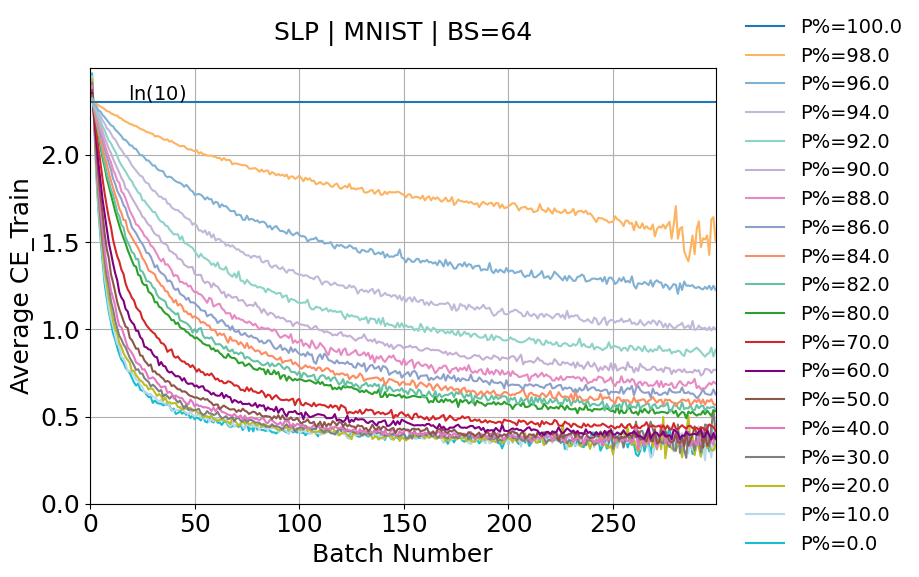

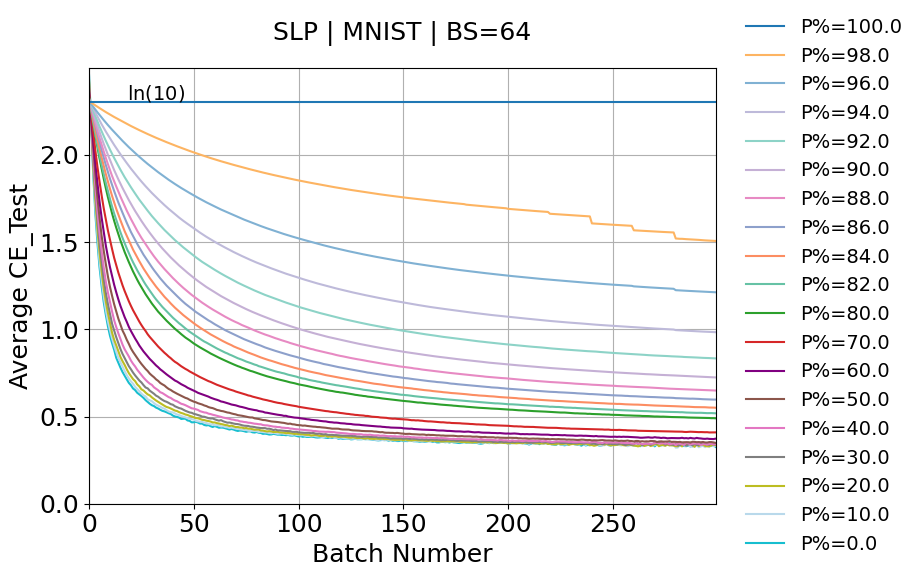

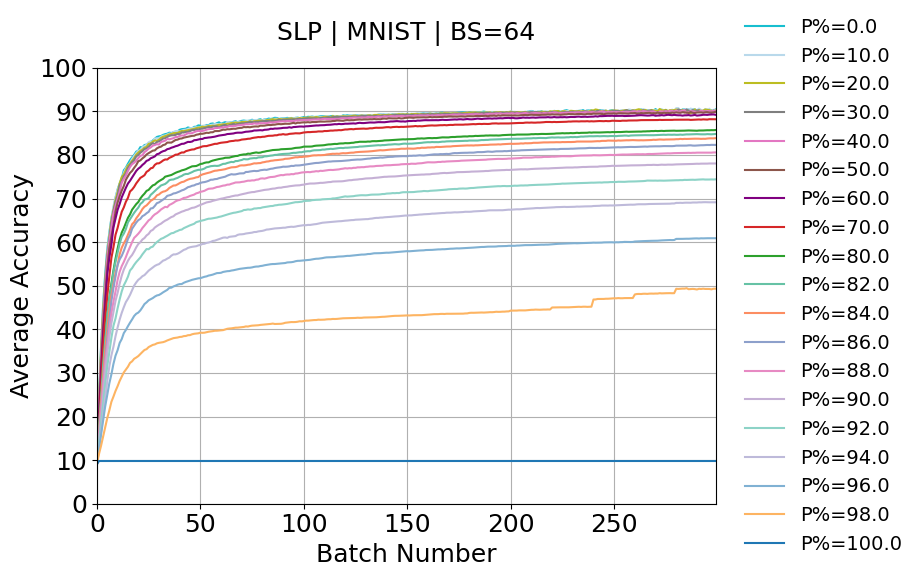

[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.0\batch_size_1024\averaged_runs_p_0.0_bs_1024.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.1\batch_size_1024\averaged_runs_p_0.1_bs_1024.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.2\batch_size_1024\averaged_runs_p_0.2_bs_1024.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.3\batch_size_1024\averaged_runs_p_0.3_bs_1024.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.4\batch_size_1024\averaged_runs_p_0.4_bs_1024.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.5\batc

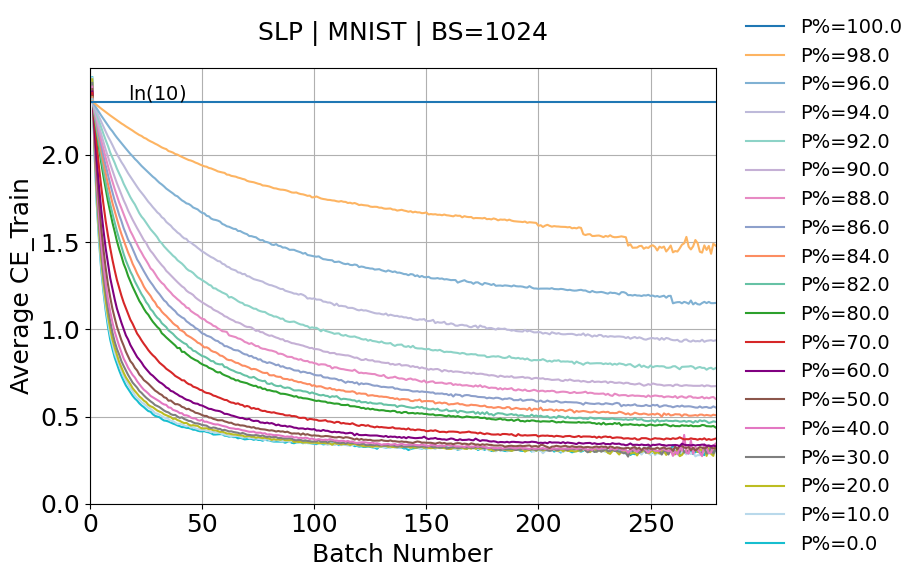

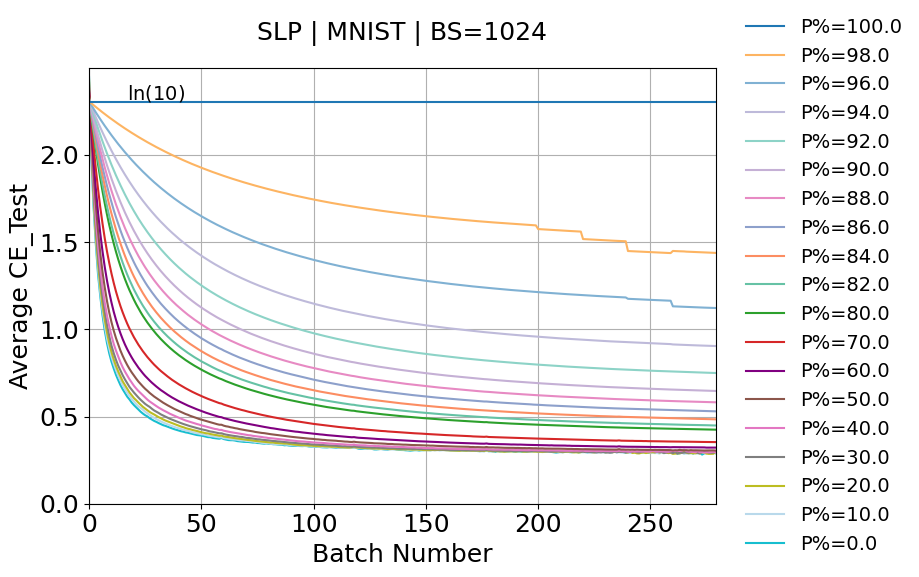

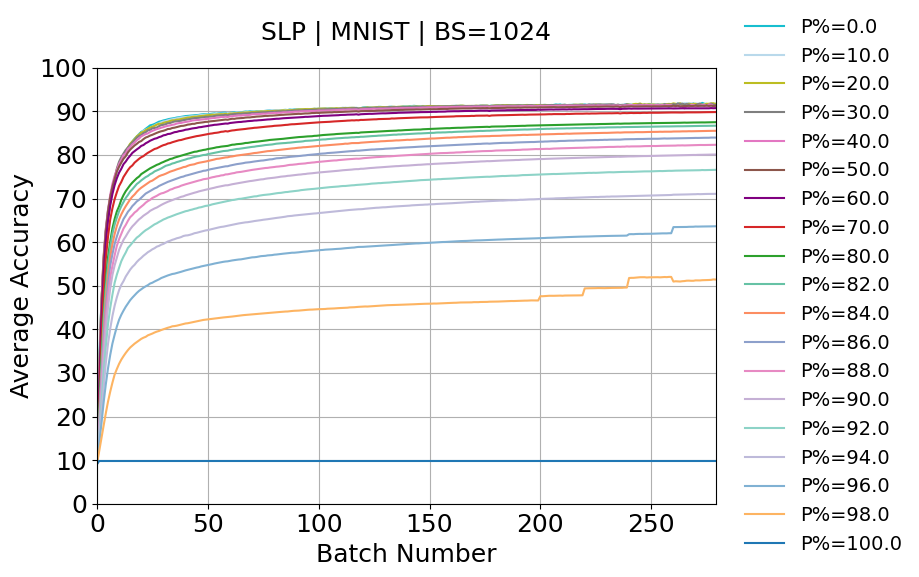

[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.0\batch_size_60000\averaged_runs_p_0.0_bs_60000.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.1\batch_size_60000\averaged_runs_p_0.1_bs_60000.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.2\batch_size_60000\averaged_runs_p_0.2_bs_60000.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.3\batch_size_60000\averaged_runs_p_0.3_bs_60000.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentage_0.4\batch_size_60000\averaged_runs_p_0.4_bs_60000.csv
[INFO] Reading averaged CSV: C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL\p-percentag

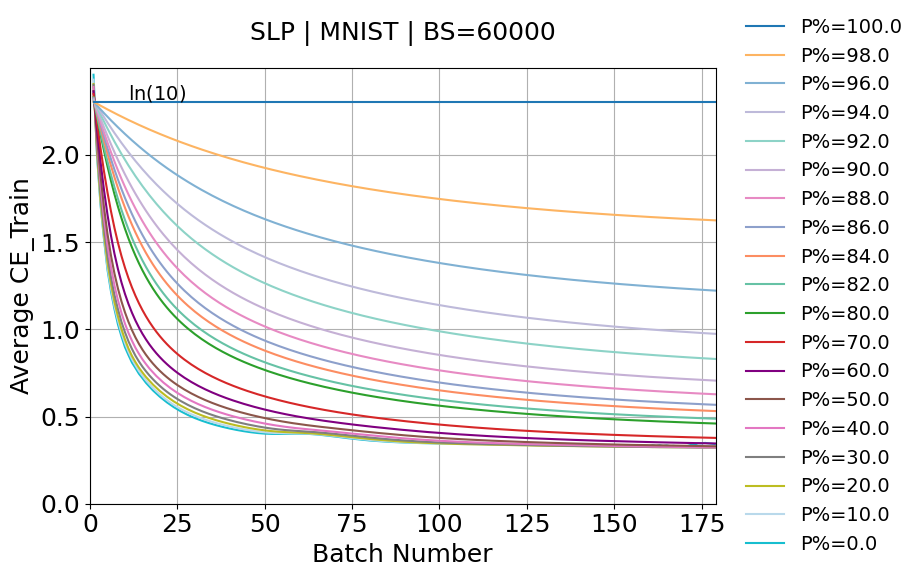

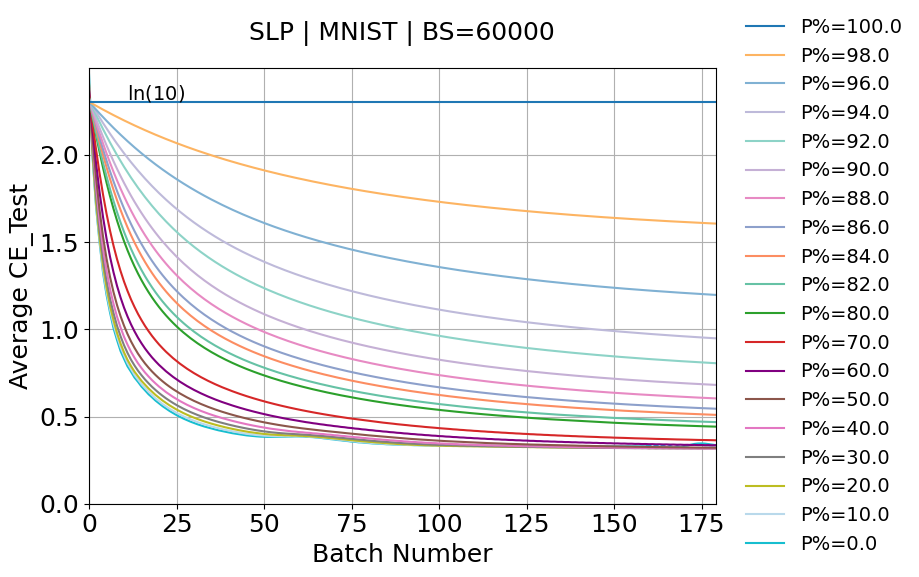

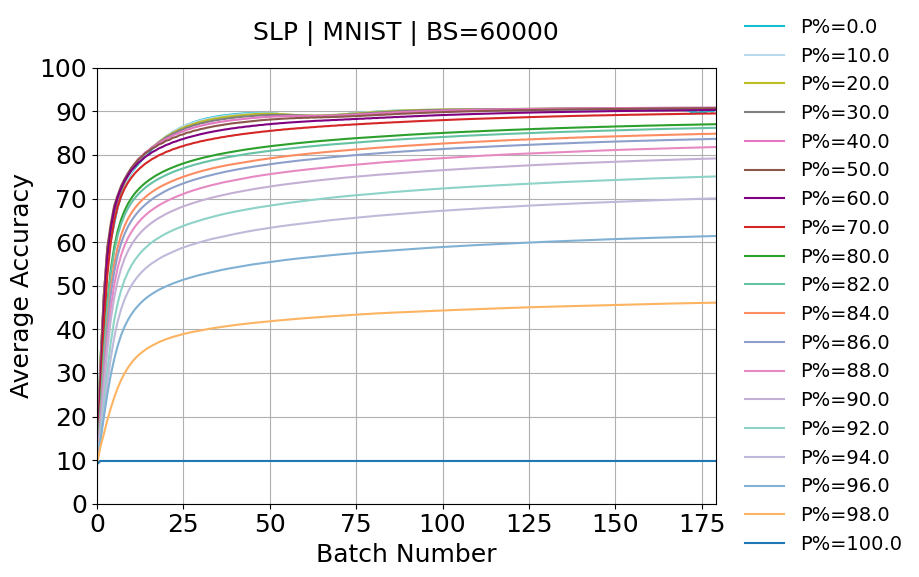

In [43]:
import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
BASE_DIR = r"C:\Users\Student\Desktop\Neural_research\physlab\SLP\SLP-MNIST\prune_layers_ALL"
BATCH_DIR_TEMPLATE = "p-percentage_{}\\batch_size_{}"
FILE_PATTERN = "slp_{}_{}_run_*"

BATCH_SIZES = [64, 1024, 60000]
LN10 = np.log(10)

# =========================
# CUSTOM PRUNING PERCENTAGES
# =========================
PRUNING_PERCENTAGES = [
    0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,
    0.8, 0.82, 0.84, 0.86, 0.88, 0.9, 0.92, 0.94, 0.96, 0.98, 1.0
]
# =========================
# STANDARD COLOR MAP
# =========================
PRUNING_COLOR_MAP = {
    0.0:   "#17becf",
    0.1:   "#B9D9EB",
    0.2:   "#bcbd22",
    0.3:   "#7f7f7f",
    0.4:   "#e377c2",
    0.5:   "#8c564b",
    0.6:   "#800080",
    0.7:   "#d62728",
    0.8:   "#2ca02c",
    0.82:  "#66c2a5",
    0.84:  "#fc8d62",
    0.86:  "#8da0cb",
    0.88:  "#e78ac3",
    0.9:   "#C5B0D5",
    0.92:  "#8DD3C7",
    0.94:  "#BEBADA",
    0.96:  "#80B1D3",
    0.98:  "#FDB462",
    0.985: "#6A5ACD",
    0.99:  "#FF6F61",
    1.0:   "#1f77b4"
}

# =========================
# STYLE
# =========================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14
})

# =========================
# LOOP OVER BATCH SIZES
# =========================
for bs in BATCH_SIZES:
    all_avg_dfs = {}

    # Only include percentages that actually exist
    for p in PRUNING_PERCENTAGES:
        folder = os.path.join(BASE_DIR, BATCH_DIR_TEMPLATE.format(p, bs))
        if not os.path.isdir(folder):
            # Skip missing folders completely
            continue

        avg_csv_path = os.path.join(folder, f"averaged_runs_p_{p}_bs_{bs}.csv")

        # =========================
        # If averaged CSV exists, read it
        # =========================
        if os.path.exists(avg_csv_path):
            print(f"[INFO] Reading averaged CSV: {avg_csv_path}")
            avg_df = pd.read_csv(avg_csv_path)
            all_avg_dfs[p] = avg_df
            continue

        # =========================
        # Otherwise, read raw run files and compute average
        # =========================
        pattern = FILE_PATTERN.format(p, bs)
        files = glob.glob(os.path.join(folder, pattern))

        if not files:
            print(f"[WARNING] No run files found for pruning {p} and batch size {bs}")
            continue

        dfs = []
        for f in files:
            try:
                df = pd.read_csv(f, sep=r"\s+")
                if df.empty:
                    continue
                df.columns = df.columns.str.strip()
                df["CE_Train"] = pd.to_numeric(df["CE_Train"], errors="coerce")
                df["CE_TEST"] = pd.to_numeric(df["CE_TEST"], errors="coerce")
                df["Accuracy(%)"] = pd.to_numeric(df["Accuracy(%)"], errors="coerce")
                dfs.append(df)
            except:
                continue

        if not dfs:
            print(f"[WARNING] No valid data for pruning {p} and batch size {bs}, skipping...")
            continue

        all_runs = pd.concat(dfs, ignore_index=True)

        avg_df = all_runs.groupby("Batch_Number", as_index=False).agg(
            Avg_CE_Train=("CE_Train", "mean"),
            Avg_CE_Test=("CE_TEST", "mean"),
            Avg_Accuracy=("Accuracy(%)", "mean"),
            Num_Runs=("CE_TEST", "count")
        )

        avg_df.to_csv(avg_csv_path, index=False)
        print(f"[INFO] Saved averaged CSV: {avg_csv_path}")
        all_avg_dfs[p] = avg_df

    # =========================
    # GLOBAL MIN MAX BATCH (exclude p=1.0)
    # =========================
    pruning_excl_1 = [p for p in all_avg_dfs.keys() if p != 1.0]
    if pruning_excl_1:
        min_max_batch = min(all_avg_dfs[p]["Batch_Number"].max() for p in pruning_excl_1)
    else:
        min_max_batch = None

    # =========================
    # PLOTTING FUNCTION
    # =========================
    def plot_metric(metric_col, ylabel, filename, reverse_legend=False, remove_top_tick=False):
        plt.figure(figsize=(12, 6))
        for p, avg_df in all_avg_dfs.items():
            if p != 1.0:
                plot_df = avg_df.copy()
                if min_max_batch is not None:
                    plot_df = plot_df[plot_df["Batch_Number"] <= min_max_batch]
            else:
                if min_max_batch is not None:
                    full_range = pd.DataFrame({"Batch_Number": np.arange(0, min_max_batch + 1)})
                    plot_df = pd.merge(full_range, avg_df[["Batch_Number", metric_col]],
                                       on="Batch_Number", how="left")
                    plot_df[metric_col] = plot_df[metric_col].ffill()
                else:
                    plot_df = avg_df.copy()

            plt.plot(plot_df["Batch_Number"], plot_df[metric_col],
                     label=f"P%={round(p * 100, 2)}",
                     color=PRUNING_COLOR_MAP.get(p, "#000000"))

        plt.xlabel("Batch Number")
        plt.ylabel(f"Average {ylabel}")
        if "Accuracy" in ylabel:
            plt.ylim(0, 100)
            plt.yticks(range(0, 101, 10))
        else:
            plt.ylim(0, 2.5)
            ticks = np.arange(0, 2.6, 0.5)
            if remove_top_tick:
                ticks = ticks[:-1]
            plt.yticks(ticks)
            plt.text(0.06, LN10 + 0.05, r"$\ln(10)$",
                     transform=plt.gca().get_yaxis_transform(),
                     fontsize=14, va="center", ha="left")
            plt.tick_params(axis='y', which='minor', length=0)

        if min_max_batch is not None:
            plt.xlim(0, min_max_batch)

        plt.title(f"SLP | MNIST | BS={bs}", pad=20)
        handles, labels = plt.gca().get_legend_handles_labels()
        if reverse_legend:
            handles, labels = handles[::-1], labels[::-1]
        plt.legend(handles, labels,
                   loc="center left",
                   bbox_to_anchor=(1.02, 0.5),
                   frameon=False)
        plt.grid(True)
        plt.tight_layout(rect=[0, 0, 0.80, 1])
        plt.savefig(f"{filename}_SLP_MNIST_BS_{bs}.png", bbox_inches="tight", dpi=300)
        plt.show()

    # =========================
    # PLOTTING METRICS
    # =========================
    plot_metric("Avg_CE_Train", "CE_Train", "CE_Train_Avg", reverse_legend=True, remove_top_tick=True)
    plot_metric("Avg_CE_Test", "CE_Test", "CE_Test_Avg", reverse_legend=True, remove_top_tick=True)
    plot_metric("Avg_Accuracy", "Accuracy", "Accuracy_Avg", reverse_legend=False)

In [44]:
import os

# =========================
# LIST OF FILES TO REMOVE
# =========================
files_to_remove = [
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.2/batch_size_1024/averaged_runs_p_0.25_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.2/batch_size_60000/averaged_runs_p_0.25_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.2/batch_size_64/averaged_runs_p_0.25_bs_64.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_1024/averaged_runs_p_0.75_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_1024/averaged_runs_p_0.82_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_1024/averaged_runs_p_0.84_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_60000/averaged_runs_p_0.75_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_60000/averaged_runs_p_0.82_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_60000/averaged_runs_p_0.84_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_64/averaged_runs_p_0.75_bs_64.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_64/averaged_runs_p_0.82_bs_64.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_64/averaged_runs_p_0.84_bs_64.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_1024/averaged_runs_p_0.86_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_1024/averaged_runs_p_0.88_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_1024/averaged_runs_p_0.92_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_1024/averaged_runs_p_0.94_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_60000/averaged_runs_p_0.86_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_60000/averaged_runs_p_0.88_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_60000/averaged_runs_p_0.92_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_60000/averaged_runs_p_0.94_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_64/averaged_runs_p_0.86_bs_64.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_64/averaged_runs_p_0.88_bs_64.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_64/averaged_runs_p_0.92_bs_64.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.9/batch_size_64/averaged_runs_p_0.94_bs_64.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_1.0/batch_size_1024/averaged_runs_p_0.96_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_1.0/batch_size_1024/averaged_runs_p_0.98_bs_1024.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_1.0/batch_size_60000/averaged_runs_p_0.96_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_1.0/batch_size_60000/averaged_runs_p_0.98_bs_60000.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_1.0/batch_size_64/averaged_runs_p_0.96_bs_64.csv",
    "SLP/SLP-MNIST/prune_layers_ALL/p-percentage_1.0/batch_size_64/averaged_runs_p_0.98_bs_64.csv"
]

# =========================
# DELETE FILES
# =========================
for file_path in files_to_remove:
    if os.path.exists(file_path):
        os.remove(file_path)
        print(f"[DELETED] {file_path}")
    else:
        print(f"[NOT FOUND] {file_path}")

[NOT FOUND] SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.2/batch_size_1024/averaged_runs_p_0.25_bs_1024.csv
[NOT FOUND] SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.2/batch_size_60000/averaged_runs_p_0.25_bs_60000.csv
[NOT FOUND] SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.2/batch_size_64/averaged_runs_p_0.25_bs_64.csv
[NOT FOUND] SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_1024/averaged_runs_p_0.75_bs_1024.csv
[NOT FOUND] SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_1024/averaged_runs_p_0.82_bs_1024.csv
[NOT FOUND] SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_1024/averaged_runs_p_0.84_bs_1024.csv
[NOT FOUND] SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_60000/averaged_runs_p_0.75_bs_60000.csv
[NOT FOUND] SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_60000/averaged_runs_p_0.82_bs_60000.csv
[NOT FOUND] SLP/SLP-MNIST/prune_layers_ALL/p-percentage_0.8/batch_size_60000/averaged_runs_p_0.84_bs_60000.csv
[NOT FOUND] SLP